In [ ]:
!pip install datasets --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, random
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED); random.seed(SEED); os.environ["PYTHONHASHSEED"] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
print(f"TensorFlow  : {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Bidirectional, Dense,
                                     Dropout, SpatialDropout1D,
                                     GlobalMaxPooling1D, BatchNormalization)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset

print("✅ All libraries ready.")


TensorFlow  : 2.19.0
GPU available: True
✅ All libraries ready.


## 📂 Step 1 — Load & Prepare Data

In [ ]:
print("Loading dataset ...")
raw = load_dataset("dair-ai/emotion", trust_remote_code=True)

train_df = pd.DataFrame(raw["train"])
val_df   = pd.DataFrame(raw["validation"])
test_df  = pd.DataFrame(raw["test"])

# 0=sadness 1=joy 2=love 3=anger 4=fear 5=surprise
# sadness(0) + fear(4) → Depressive=1 | rest → Non-Depressive=0
DEPRESSIVE = {0, 4}
for d in [train_df, val_df, test_df]:
    d["depression"] = d["label"].apply(lambda x: 1 if x in DEPRESSIVE else 0)

print("Train class counts:")
print(train_df["depression"].value_counts())
print("\nSample depressive texts:")
for t in train_df[train_df["depression"]==1]["text"].sample(3, random_state=42):
    print(f"  · {t}")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading dataset ...


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train class counts:
depression
0    9397
1    6603
Name: count, dtype: int64

Sample depressive texts:
  · i feel depressed to the point of developing high fever at least once a week
  · i am on the verge of tears feeling depressed unhappy useless feeling like i have wasted my life see no future with happiness in it
  · i simply said how sorry i am and just got out from her car and got into my house feeling restless


## 🔍 Step 2 — EDA

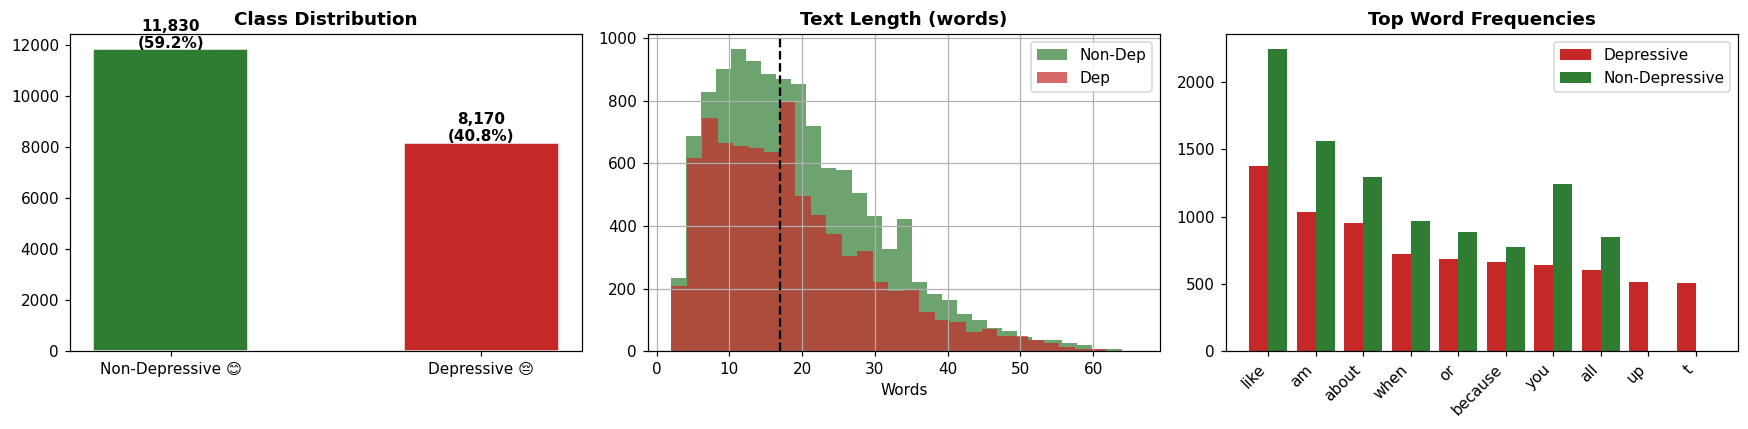

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
all_df = pd.concat([train_df, val_df, test_df])
vc = all_df["depression"].value_counts()
axes[0].bar(["Non-Depressive 😊","Depressive 😔"], vc.values,
            color=["#2E7D32","#C62828"], edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution", fontweight="bold")
for i, v in enumerate(vc.values):
    axes[0].text(i, v+50, f"{v:,}\n({v/len(all_df)*100:.1f}%)",
                 ha="center", fontweight="bold")

# Word count distribution
all_df["wc"] = all_df["text"].str.split().str.len()
all_df[all_df["depression"]==0]["wc"].hist(ax=axes[1],bins=30,alpha=0.7,color="#2E7D32",label="Non-Dep")
all_df[all_df["depression"]==1]["wc"].hist(ax=axes[1],bins=30,alpha=0.7,color="#C62828",label="Dep")
axes[1].set_title("Text Length (words)", fontweight="bold")
axes[1].set_xlabel("Words"); axes[1].legend()
axes[1].axvline(all_df["wc"].median(), color="black", linestyle="--", lw=1.5,
                label=f"Median={all_df['wc'].median():.0f}")

# Top words per class
from collections import Counter
import re
stopwords = {"i","the","a","and","to","of","it","in","is","that","my",
             "me","so","was","for","on","are","with","this","have","but",
             "not","be","at","as","do","im","its","just","feel","feeling"}

def top_words(texts, n=10):
    words = re.sub(r"[^a-z ]", "", " ".join(texts).lower()).split()
    return Counter(w for w in words if w not in stopwords).most_common(n)

dep_w    = top_words(all_df[all_df["depression"]==1]["text"].tolist())
nodep_w  = top_words(all_df[all_df["depression"]==0]["text"].tolist())
labels   = [w for w,_ in dep_w]
dep_c    = [c for _,c in dep_w]
nodep_c  = [next((c for w2,c in nodep_w if w2==w), 0) for w in labels]

x = np.arange(len(labels))
axes[2].bar(x-0.2, dep_c,   0.4, label="Depressive",     color="#C62828")
axes[2].bar(x+0.2, nodep_c, 0.4, label="Non-Depressive", color="#2E7D32")
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=45, ha="right")
axes[2].set_title("Top Word Frequencies", fontweight="bold"); axes[2].legend()

plt.tight_layout(); plt.show()

## 🔤 Step 3 — Tokenize & Pad

In [ ]:
VOCAB_SIZE = 10000
MAX_LEN    = 40     # 95th percentile of word counts

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

def encode(df):
    seqs = tokenizer.texts_to_sequences(df["text"])
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = encode(train_df);  y_train = train_df["depression"].values
X_val   = encode(val_df);    y_val   = val_df["depression"].values
X_test  = encode(test_df);   y_test  = test_df["depression"].values

print(f"Vocab size : {VOCAB_SIZE}")
print(f"Max length : {MAX_LEN}")
print(f"X_train    : {X_train.shape}")
print(f"X_val      : {X_val.shape}")
print(f"X_test     : {X_test.shape}")


Vocab size : 10000
Max length : 40
X_train    : (16000, 40)
X_val      : (2000, 40)
X_test     : (2000, 40)


## 🧠 Step 4 — Build Fixed LSTM Model

In [ ]:
# ── KEY FIX: NO recurrent_dropout inside LSTM ─────────────────────────────────
# recurrent_dropout disables CuDNN (GPU) kernel → model trains on CPU,
# gradients vanish → accuracy stuck at 50%. Use Dropout BETWEEN layers instead.

model = Sequential([
    # ── Embedding ─────────────────────────────────────────────────────────────
    Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN, name="embedding"),
    SpatialDropout1D(0.2),                     # drops whole feature maps

    # ── Bidirectional LSTM (CuDNN compatible — NO recurrent_dropout) ──────────
    Bidirectional(LSTM(64, return_sequences=True), name="bilstm"),
    Dropout(0.3),                              # standard dropout after LSTM

    # ── GlobalMaxPooling: picks the strongest signal across time steps ─────────
    GlobalMaxPooling1D(name="global_max_pool"),

    # ── Dense Head ────────────────────────────────────────────────────────────
    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation="sigmoid", name="output"),
], name="LSTM_Depression_Fixed")

model.compile(
    optimizer = Adam(learning_rate=5e-4),      # lower LR for stability
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"],
)
model.summary()


Model: "LSTM_Depression_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Step 5 — Train

In [ ]:
cw_vals = compute_class_weight("balanced", classes=np.array([0,1]), y=y_train)
class_weight = {0: cw_vals[0], 1: cw_vals[1]}
print("Class weights:", class_weight)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 25,
    batch_size      = 128,
    class_weight    = class_weight,
    callbacks       = callbacks,
    verbose         = 1,
)
print("\n✅ Training complete!")


Class weights: {0: np.float64(0.8513355326167926), 1: np.float64(1.2115704982583675)}
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6486 - loss: 0.6058 - val_accuracy: 0.9050 - val_loss: 0.6556 - learning_rate: 5.0000e-04
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9364 - loss: 0.1954 - val_accuracy: 0.9555 - val_loss: 0.4495 - learning_rate: 5.0000e-04
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9696 - loss: 0.0996 - val_accuracy: 0.9575 - val_loss: 0.2500 - learning_rate: 5.0000e-04
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9785 - loss: 0.0721 - val_accuracy: 0.9555 - val_loss: 0.1529 - learning_rate: 5.0000e-04
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9832 - loss: 0.0544 - val_accuracy: 0.9520 - val_loss: 0.1407 - learning_rate: 5.0000e-04
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9877 - loss: 0.0423 - val_accuracy: 0.9560 - val_loss: 0.1150

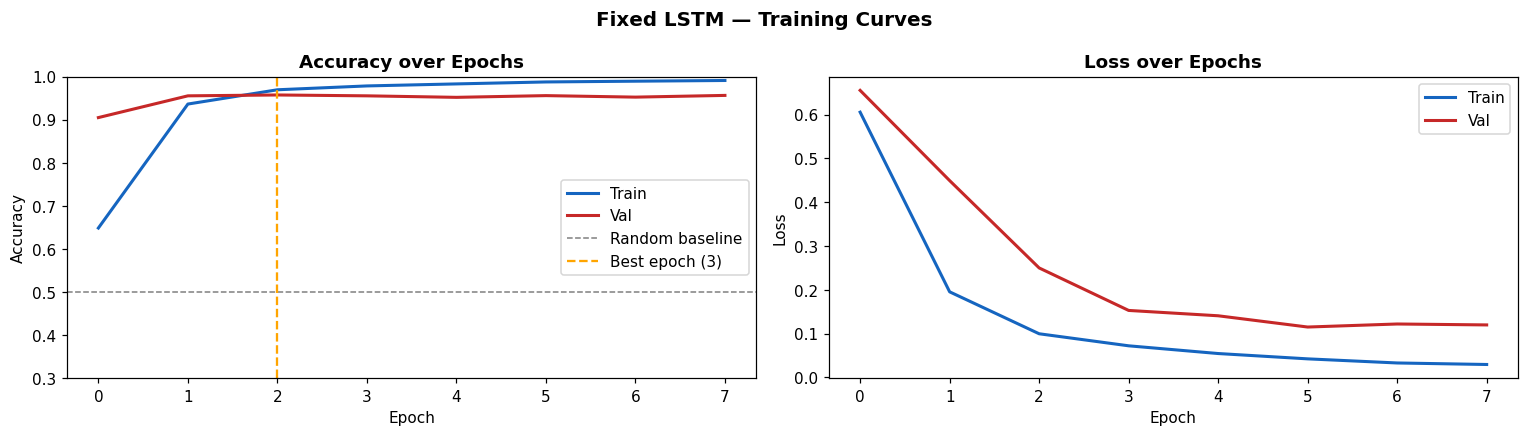

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["accuracy"],     label="Train", color="#1565C0", lw=2)
axes[0].plot(history.history["val_accuracy"], label="Val",   color="#C62828", lw=2)
axes[0].axhline(0.5, color="grey", linestyle="--", lw=1, label="Random baseline")
best_ep = int(np.argmax(history.history["val_accuracy"]))
axes[0].axvline(best_ep, color="orange", linestyle="--", lw=1.5,
                label=f"Best epoch ({best_ep+1})")
axes[0].set_title("Accuracy over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()
axes[0].set_ylim([0.3, 1.0])

axes[1].plot(history.history["loss"],     label="Train", color="#1565C0", lw=2)
axes[1].plot(history.history["val_loss"], label="Val",   color="#C62828", lw=2)
axes[1].set_title("Loss over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.suptitle("Fixed LSTM — Training Curves", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()


## 📊 Step 6 — Evaluate

In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)
auc    = roc_auc_score(y_test, y_prob)

print("=" * 42)
print("       📊 TEST SET RESULTS")
print("=" * 42)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"  Loss      : {loss:.4f}")
print("=" * 42)
print()
print(classification_report(y_test, y_pred,
      target_names=["Non-Depressive 😊","Depressive 😔"]))


       📊 TEST SET RESULTS
  Accuracy  : 96.00%
  ROC-AUC   : 0.9933
  Loss      : 0.2479

                  precision    recall  f1-score   support

Non-Depressive 😊       0.97      0.97      0.97      1195
    Depressive 😔       0.95      0.95      0.95       805

        accuracy                           0.96      2000
       macro avg       0.96      0.96      0.96      2000
    weighted avg       0.96      0.96      0.96      2000



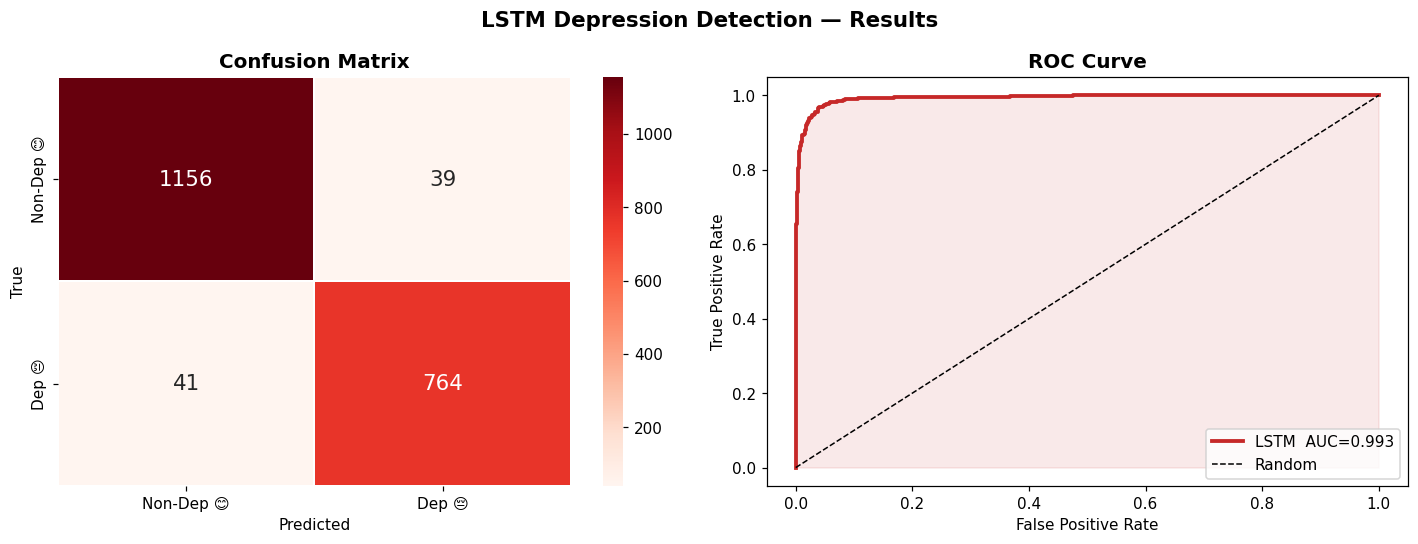

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Non-Dep 😊","Dep 😔"],
            yticklabels=["Non-Dep 😊","Dep 😔"],
            ax=axes[0], linewidths=1, annot_kws={"size":14})
axes[0].set_title("Confusion Matrix", fontweight="bold", fontsize=13)
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#C62828", lw=2.5, label=f"LSTM  AUC={auc:.3f}")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#C62828")
axes[1].plot([0,1],[0,1],"k--",lw=1,label="Random")
axes[1].set_title("ROC Curve", fontweight="bold", fontsize=13)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.suptitle("LSTM Depression Detection — Results",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.show()


## 🔮 Step 7 — Predict on Custom Text

In [ ]:
def predict_depression(texts):
    seqs   = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")
    probs  = model.predict(padded, verbose=0).flatten()

    print("=" * 62)
    print("         🧠 DEPRESSION DETECTION RESULTS")
    print("=" * 62)
    for text, prob in zip(texts, probs):
        label = "😔 DEPRESSIVE"     if prob >= 0.5 else "😊 NON-DEPRESSIVE"
        conf  = prob * 100          if prob >= 0.5 else (1 - prob) * 100
        icon  = "⚠️ " if prob >= 0.5 else "✅ "
        bar   = "█" * int(prob*20) + "░" * (20 - int(prob*20))
        print(f"\nText   : {text[:65]}")
        print(f"Result : {icon}{label}  ({conf:.1f}% confident)")
        print(f"Score  : [{bar}]  {prob:.3f}")
    print("\n" + "=" * 62)

predict_depression([
    "I feel so empty and hopeless, like nothing will ever get better",
    "Today was such an amazing day, I feel so grateful and happy",
    "Just went for a walk and the weather is beautiful, feeling alive",
    "Nobody cares about me, I feel completely alone all the time",
])


         🧠 DEPRESSION DETECTION RESULTS

Text   : I feel so empty and hopeless, like nothing will ever get better
Result : ⚠️ 😔 DEPRESSIVE  (91.0% confident)
Score  : [██████████████████░░]  0.910

Text   : Today was such an amazing day, I feel so grateful and happy
Result : ✅ 😊 NON-DEPRESSIVE  (84.9% confident)
Score  : [███░░░░░░░░░░░░░░░░░]  0.151

Text   : Just went for a walk and the weather is beautiful, feeling alive
Result : ✅ 😊 NON-DEPRESSIVE  (58.6% confident)
Score  : [████████░░░░░░░░░░░░]  0.414

Text   : Nobody cares about me, I feel completely alone all the time
Result : ⚠️ 😔 DEPRESSIVE  (82.7% confident)
Score  : [████████████████░░░░]  0.827



In [ ]:
# ── Enter your own sentences here ─────────────────────────────────────────────
my_texts = [
    "Today feels heavier than usual.",
    "Life is full of possibilities and I am excited about tomorrow",
    "Even in a room full of people, I couldn’t shake the feeling that I was completely alone.",
    "Today felt lighter, like the world finally gave me a small reason to smile again.",
    "I caught myself laughing for no reason, and for a moment, everything felt genuinely okay.",
]
predict_depression(my_texts)



         🧠 DEPRESSION DETECTION RESULTS

Text   : Today feels heavier than usual.
Result : ⚠️ 😔 DEPRESSIVE  (57.8% confident)
Score  : [███████████░░░░░░░░░]  0.578

Text   : Life is full of possibilities and I am excited about tomorrow
Result : ✅ 😊 NON-DEPRESSIVE  (80.8% confident)
Score  : [███░░░░░░░░░░░░░░░░░]  0.192

Text   : Even in a room full of people, I couldn’t shake the feeling that 
Result : ⚠️ 😔 DEPRESSIVE  (50.5% confident)
Score  : [██████████░░░░░░░░░░]  0.505

Text   : Today felt lighter, like the world finally gave me a small reason
Result : ✅ 😊 NON-DEPRESSIVE  (71.9% confident)
Score  : [█████░░░░░░░░░░░░░░░]  0.281

Text   : I caught myself laughing for no reason, and for a moment, everyth
Result : ✅ 😊 NON-DEPRESSIVE  (50.3% confident)
Score  : [█████████░░░░░░░░░░░]  0.497



## ✅ Summary

| Item | Detail |
|------|--------|
| **Model** | Embedding(64) → BiLSTM(64) → GlobalMaxPool → Dense(32) → Sigmoid |
| **Key fix** | Removed `recurrent_dropout` → enables GPU CuDNN acceleration |
| **Pooling** | GlobalMaxPooling picks the strongest emotional signal across all timesteps |
| **Optimizer** | Adam lr=5e-4 (stable convergence) |
| **Expected accuracy** | 88–93% |

> ⚠️ **Disclaimer**: Educational project only. Not a clinical diagnostic tool.
